![bse_logo_textminingcourse](https://bse.eu/sites/default/files/bse_logo_small.png)

# Part 1: Scraping

Design and implement a mini research project in which you research the effect of a big
annual event in Barcelona on rental prices on booking by scraping data for at least two
separate weeks (important note that search results go across different pages) for Barcelona
and at least one more city.

1. Identify a (future) event that makes a lot of people come to Barcelona. Think about
music festivals, local festivities etc.
2. Think of the time periods to scrape and what second city to scrape. The second city
will be your control group. Explain your choices in written.
3. Design a careful scraping pipeline that follows the advises seen in class and TAs. The basic points to bear in mind are:
    - Organize the data you need, format and structure to store it beforehand. Try to foresee how you will need to read in the data to answer your questions. If you want, you can include some few lines explaining your pipeline strategy at the beginning.
    - Codes should be as automated as possible. That is, you don’t want to rely on human intervention to get your data.
    - Use only the packages we have seen in the course. Although firefox is recommended, you can also use chrome as your scraping browser.
    - Document your codes and make them robust and efficient.

**Chosen event**: Mobile World Congress (3rd to 6th March in 2025).

Alternatives:
- La Mercè (24th September).
- Primavera Sound.

**Second city to scrape**: Madrid.

## 0. Packages

In [1]:
from selenium.webdriver.common.by import By
from selenium.common.exceptions import (
    NoSuchElementException,
    ElementClickInterceptedException,
    StaleElementReferenceException,
)
from auxiliary_functions import (
    generate_date_ranges, get_displayed_dates, load_all_results, 
    scroll_and_click_dates, scroll_and_click, start_up
)
from selenium import webdriver
import os
import time
from datetime import datetime
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.firefox.options import Options

# We import a module that allows to input keys
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains

import pandas as pd

# Go get geckodriver from : https://github.com/mozilla/geckodriver/releases

## 1. Data to be scraped

The following attributes may be of interest for this homework:
- Name of the accommodation.
- Price.
- Rating.
- Characteristics of the accomodation (description). E.g., "Habitación Doble con baño privado - 1 o 2 camas; Camas: 1 doble o 2 individuales".

Secondary attributes:
- Neighborhood.

## 2. Search hierarchy

When searching for elements in HTML, it's common to use either XPath or CSS selectors. The choice of selector depends on the specific requirements and context of the task. Below is a basic guide to understanding the structure of these selectors.

1. **ID**: 
   - **Description**: Unique identifier for an element. Not always available.
   - **Format**: `id="unique_id"`
2. **Class**:
   - **Description**: Class name(s) associated with an element.
   - **Format**: `class="class_name"`
3. **Tag**:
   - **Description**: HTML tag (like `div`, `label`, etc.).
   - **Format**: `<tag>`
4. **Attribute**:
   - **Description**: An attribute and its value within an element.
   - **Format**: `attribute="attribute_value"`

### XPath

- **Basic Structure**:
  
  ```xpath
  //tag[@attribute="attribute_value"][position]

The double bar `//` selects all elements that match that path. As in regex, you can use * to match any element

### CSS

You also have CSS selectors that will match elements based on attributes. These are easier but less robust than xpath. Sometimes they will allow you to differentitate HTML elements that would otherwise be equal

``` <span class ="green"></span>
<span class ="red"></span>

With their class, you can get say all the links that are green but not red. 

## 3. Organization of the data

Each row of the data frame can be one data extraction with the following information:
- Name of the accommodation.
- Price.
- Date of beginning of rental.
- Date of end of rental.
- Description of the accommodation.
- Neighborhood.

## 4. Scraping

In [2]:
# We set as the download directory the folder 'files',
# defined through a relative path
dfolder = "./files"
# Set the geckodriver path
geko_path = "/usr/local/bin/geckodriver"
# Link to booking
link = "https://www.booking.com/index.es.html"

browser = start_up(dfolder=dfolder, link=link, geko_path=geko_path, ubuntu = True)

In [22]:
# We have to reject the cookies to simplify the process of putting buttons into
# view (which is useful when we want to click a button that may be obscured 
# otherwise)
path = '//*[@id="onetrust-reject-all-handler"]'
browser.find_element(by="xpath", value= path).click()

In [13]:
# We scroll and click on the "Where are you going?" search button
scroll_and_click(browser = browser, by_type = 'xpath', path = '//*[@id=":rh:"]')
# Input the destination for which you want to search accommodations
place = "Barcelona"
search1 = browser.find_element(by="xpath", value='//*[@id=":rh:"]')
search1.send_keys(place)

In [14]:
# Use ActionChains to press Tab 6 times, to remove the pop-up list that appears
# to select the destination
actions = ActionChains(browser)
for _ in range(6):
    actions.send_keys(Keys.TAB).pause(0.05)
actions.perform()

# Scroll and click on the calendar button
css = "button.ebbedaf8ac:nth-child(2) > span:nth-child(1)"
scroll_and_click(browser = browser, by_type = 'css selector', path = css)

In [17]:
# We select the dates
## Set the path for the date buttons
path = '//div[@id="calendar-searchboxdatepicker"]//table[@class="eb03f3f27f"]//tbody//td[@class="b80d5adb18"]//span[@class="cf06f772fa ef091eb985"]'
## Set the dates (yyyy-mm-dd)
start_date = f"2025-01-26"
end_date = f"2025-01-31"
## Scroll for visibility and click on the desired dates
scroll_and_click_dates(browser, "xpath", path, start_date, end_date)

Now, we should design the code such that:
- It looks for one week shown in the calendar.
- It makes the search.
- It retrieves the desired information from the available accommodations.
- It changes the dates and searches for another week.
- It retrieves the desired information for the new week.
- And successively.

In [18]:
# Scroll up until calendar button is visible again and click
css = "button.ebbedaf8ac:nth-child(2) > span:nth-child(1)"
scroll_and_click(browser = browser, by_type = 'css selector', path = css)

In [19]:
# Once we are outside the date selector, we click on the search button
my_xpath = '//div[@id="indexsearch"]//div[@class="ffb9c3d6a3 b3b8f00b52 c9a7790c31 e691439f9a"]//button[@class="a83ed08757 c21c56c305 a4c1805887 f671049264 a2abacf76b c082d89982 cceeb8986b b9fd3c6b3c"]'
browser.find_element(by = "xpath", value = my_xpath).click()

Let's try to get hotel names. To extend this, the idea should be to do a loop where:
1. We scroll down as much as possible, until no new hotels are loaded (i.e., until we reach the button "Cargar más resultados").
2. We click the button "Cargar más resultados".
3. We scroll down again with the same idea, until we can click the reload button.
4. And successively until there are no new accommodations that can be loaded.
5. Once all of the accomodations have been loaded, we extract all the accomodation info.

In [120]:
# We click on the cross to dismiss the Genius pop-up that appears prompting for
# signing up or signing in. If the button does not exist, it simply continues
path = '//div[@class="f0c216ee26 c676dd76fe b5018b639f"]//button[@class="a83ed08757 c21c56c305 f38b6daa18 d691166b09 ab98298258 f4552b6561"]'
try:
    browser.find_element(by="xpath", value=path).click() # Click the button if it exists
except:
    pass # Do nothing if the button is not found

In [20]:
path = '//div[@class="c82435a4b8 f581fde0b8"]//button[@class="a83ed08757 c21c56c305 bf0537ecb5 f671049264 af7297d90d c0e0affd09"]'
# If it doesn't load all results, try increasing the scroll pause (in seconds)
# Efficiency increases by reducing the scroll pause, at the cost of possibly 
# not getting all of the results if the page doesn't load quickly
load_all_results(browser = browser, 
                 button_xpath = path, 
                 scroll_pause=0.25, max_attempts=50)

InvalidSessionIdException: Message: WebDriver session does not exist, or is not active
Stacktrace:
RemoteError@chrome://remote/content/shared/RemoteError.sys.mjs:8:8
WebDriverError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:193:5
InvalidSessionIDError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:448:5
assert.that/<@chrome://remote/content/shared/webdriver/Assert.sys.mjs:515:13
assert.session@chrome://remote/content/shared/webdriver/Assert.sys.mjs:37:4
despatch@chrome://remote/content/marionette/server.sys.mjs:315:19
execute@chrome://remote/content/marionette/server.sys.mjs:289:16
onPacket/<@chrome://remote/content/marionette/server.sys.mjs:262:20
onPacket@chrome://remote/content/marionette/server.sys.mjs:263:9
_onJSONObjectReady/<@chrome://remote/content/marionette/transport.sys.mjs:494:20


Some hotels lack a rating and/or other information! To make a more robust extraction, below we loop over each accommodation "box" and try to extract all the information box by box, so that there are no mismatches (for example, attributing a certain rating to the next hotel).

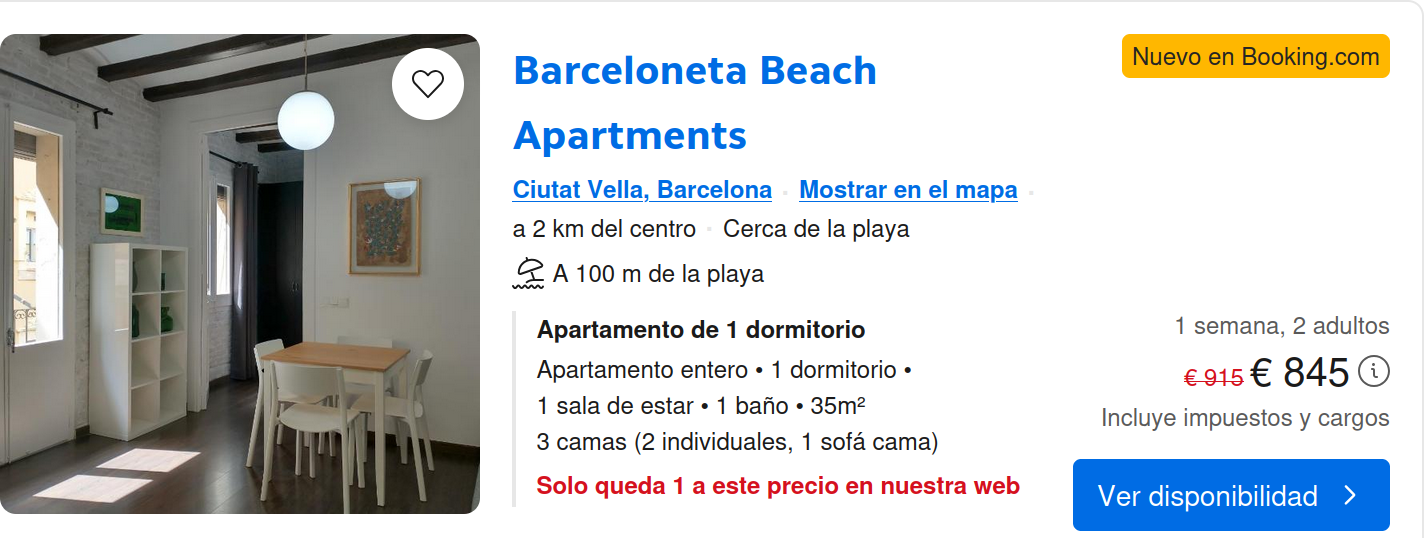

In [85]:
# We analyze the data for each accommodation box by box within a loop

## Define the XPath for the accommodation blocks
block_xpath = '//div[@class="c82435a4b8 a178069f51 a6ae3c2b40 a18aeea94d d794b7a0f7 f53e278e95 c6710787a4"]'

## Initialize a dictionary with empty lists to store accommodation data
accommodation_data = {
    "hotel_name": [],
    "price_euros": [],
    "rating": [],
    "description": [],
    "neighborhood": []
    }

## Find all accommodation blocks
accommodation_blocks = browser.find_elements("xpath", block_xpath)

## Loop over each accommodation block, setting relative paths to the block_xpath
for block in accommodation_blocks:
    try:
        # Extract the hotel name within the block
        hotel_name = block.find_element(
            "xpath", './/div[@class="f6431b446c a15b38c233"]' # Note that with .// we set it as a relative path to the block_xpath
        ).text
    except:
        hotel_name = None  # Handle cases where the hotel name is not found
    
    try:
        # Extract and clean the price within the block
        price_string = block.find_element(
            "xpath", './/span[@class="f6431b446c fbfd7c1165 e84eb96b1f"]'
        ).text
        price = float(price_string.split(" ")[1])  # Keep only the numeric part of prices and converting them to floats
    except:
        price = None  # Handle cases where the price is not found

    # Try to find the rating using multiple possible XPaths
    rating = None  # Default value if no rating is found
    possible_rating_paths = [
        './/div[@class="a3b8729ab1 d86cee9b25"]',  # First possible XPath (the most common)
        './/div[@class="a3b8729ab1 e6208ee469 cb2cbb3ccb"]',  # Second possible XPath (external comments)
    ]
    for path in possible_rating_paths:
        try:
            rating_string = block.find_element("xpath", path).text
             # Clean the rating: keep the last 3 characters and replace commas with dots
            rating = float(rating_string[-3:].replace(",", "."))
            if rating:  # If a valid rating is found, exit the loop
                break
        except:
            continue  # Try the next XPath if the current one fails
    
    try:
        # Extract the description within the block
        description = block.find_element(
            "xpath", './/div[@class="c19beea015"]'
        ).text
    except:
        description = None  # Handle cases where the description is not found

    try:
        # Extract the neighborhood within the block
        neighborhood = block.find_element(
            "xpath", './/div[@class="abf093bdfe ecc6a9ed89"]//span[@class="aee5343fdb def9bc142a"]'
        ).text
    except:
        neighborhood = None  # Handle cases where the neighborhood is not found

    # Append the data to the dictionary
    accommodation_data["hotel_name"].append(hotel_name)
    accommodation_data["price_euros"].append(price)
    accommodation_data["rating"].append(rating)
    accommodation_data["description"].append(description)
    accommodation_data["neighborhood"].append(neighborhood)

In [86]:
df = pd.DataFrame(accommodation_data)
df.head()

,hotel_name,price_euros,rating,description,neighborhood
0,Sunotel Central,672.0,8.0,Habitación Doble con balcón\nCamas: 1 doble o ...,"Eixample, Barcelona"
1,Tembo Barcelona,851.0,8.8,Estudio con 1 cama grande\nEstudio entero • 1 ...,Barcelona
2,Vincci Bit,615.0,8.5,Habitación Doble - 1 o 2 camas\nCamas: 1 doble...,"Sant Martí, Barcelona"
3,Moxy Barcelona,803.0,8.1,Habitación Moxy con balcón - Cama grande\n1 ca...,"Sants-Montjuïc, Barcelona"
4,Motel One Barcelona-Ciutadella,760.0,8.8,Habitación Doble\n1 cama doble\nCancelación gr...,"Sant Martí, Barcelona"


This method seems to work in creating null values for the accommodations for which there are no ratings, such as:

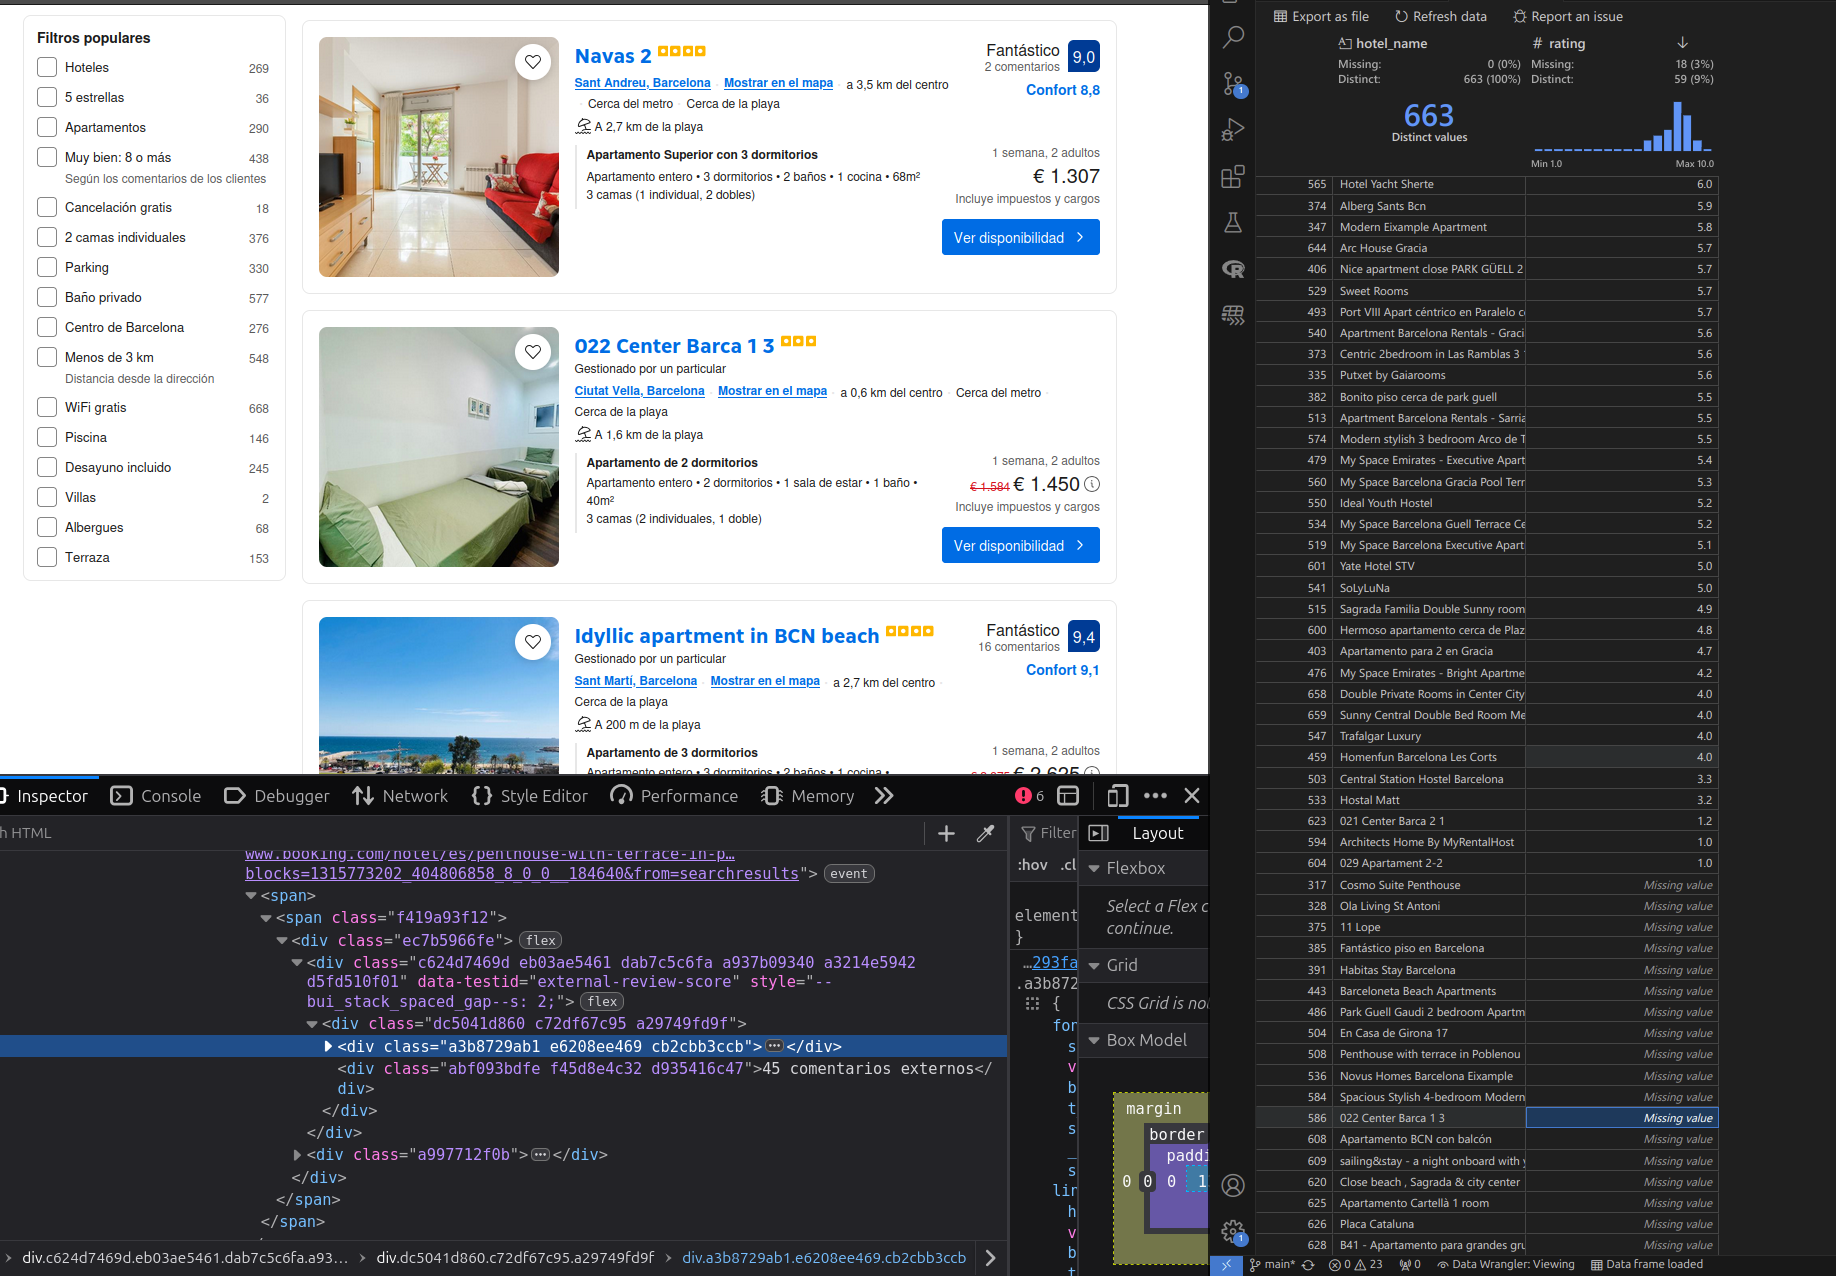

However, there are some ratings which need an adjustment (those with external comments!), as even if they have a rating they are not included. Nevertheless, this possibility is considered in the code above:

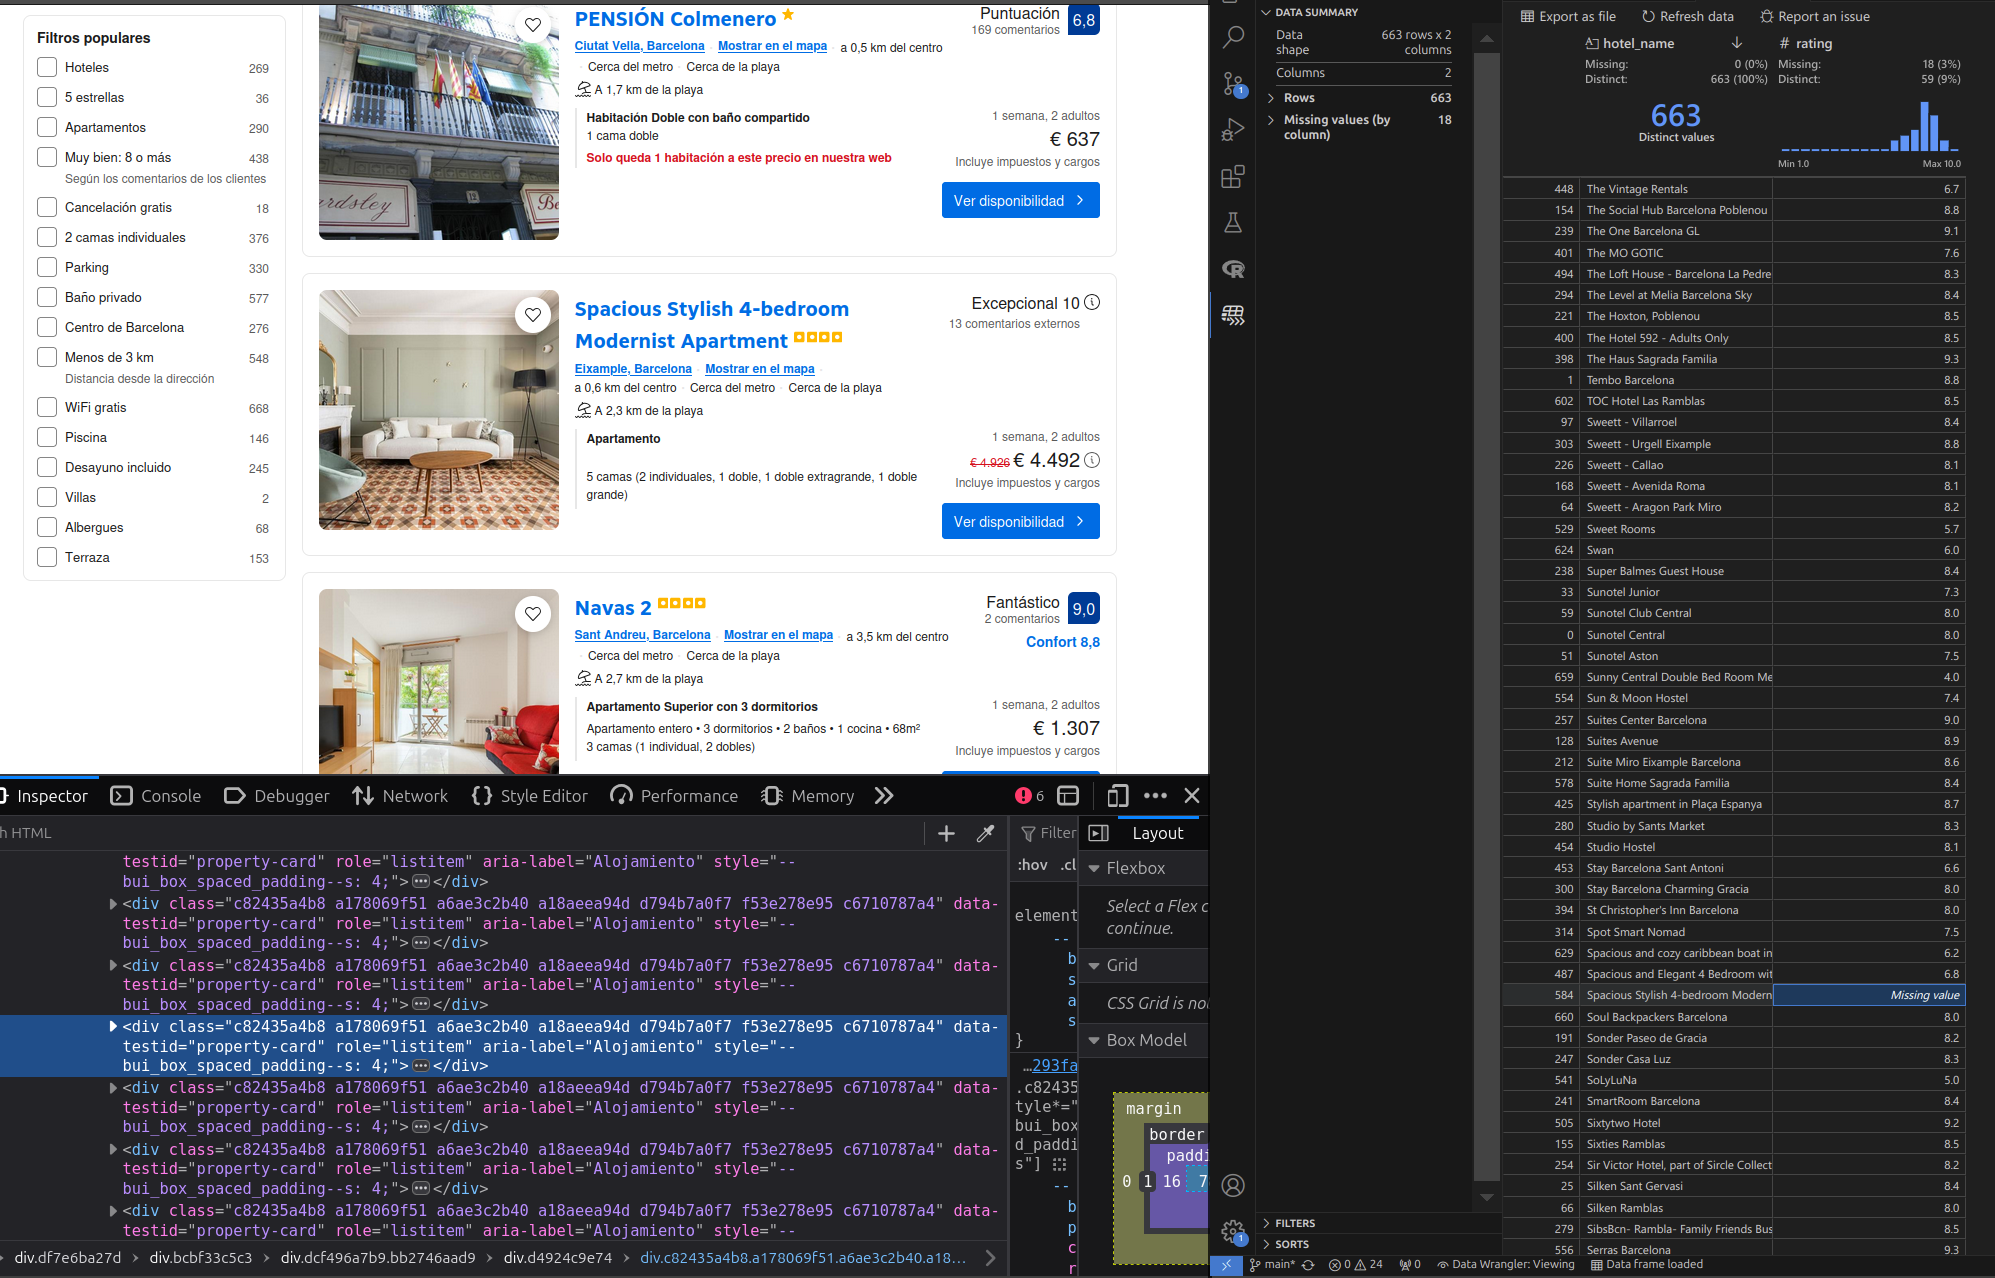

Also, there doesn't seem to be any mismatch after checking for the ratings of the last accommodations. **Conclusion**: *the method is robust and works!*.

WARNING! The number of accommodations it saves does not completely match the number of results of Booking (but by a small margin, like 664 accommodations out of 676 found). However, sometimes it seems to get all of the accommodations. In those cases, it is possible because of how a certain block that shows an accommodation is structured (for instance, I've seen that those which are advertised accommodations are not included, but there are other cases which I haven't detected).

In [97]:
# Go back to the initial booking.com page to repeat the procedure for different dates
path = '//header[@class=" Header_root"]//div[@class="Header_logo"]'
scroll_and_click(browser = browser, by_type = 'xpath', path = path)

In [123]:
test = pd.read_csv('test_results.csv')
test.head()

,Unnamed: 0,hotel_name,price_euros,rating,description,neighborhood
0,0,Lamaro Hotel,1.145,9.0,Habitación Elegance,"Ciutat Vella, Barcelona"
1,1,Tembo Barcelona,851.000,8.8,Estudio Estándar\nEstudio entero • 1 baño • 27...,Barcelona
2,2,Vincci Bit,615.000,8.5,Habitación Doble - 1 o 2 camas\nCamas: 1 doble...,"Sant Martí, Barcelona"
3,3,Moxy Barcelona,803.000,8.1,Habitación Moxy con balcón - Cama grande\n1 ca...,"Sants-Montjuïc, Barcelona"
4,4,Motel One Barcelona-Ciutadella,760.000,8.8,Habitación Doble\n1 cama doble\nCancelación gr...,"Sant Martí, Barcelona"


### Second (and subsequent) runs
Now we're back again to the main page. The idea would be to select the next week that is considered, for which we must take into account that it may not be displayed at first in the calendar. If not displayed, it should click on the button for advancing on the calendar as many times as needed.

In [5]:
# Dates selected to do the analysis
start_year = 2025
start_month = 2
end_year = 2025
end_month = 12

all_date_ranges = []
for year in range(start_year, end_year + 1):
    for month in range(start_month, end_month + 1):
        all_date_ranges.extend(generate_date_ranges(year, month))

# We print all of the tuples of dates considered for scraping
print(all_date_ranges)
# We print from the second tuple the end date (example)
print(all_date_ranges[1][1])

[('2025-02-01', '2025-02-08'), ('2025-02-09', '2025-02-16'), ('2025-02-17', '2025-02-24'), ('2025-03-01', '2025-03-08'), ('2025-03-09', '2025-03-16'), ('2025-03-17', '2025-03-24'), ('2025-04-01', '2025-04-08'), ('2025-04-09', '2025-04-16'), ('2025-04-17', '2025-04-24'), ('2025-05-01', '2025-05-08'), ('2025-05-09', '2025-05-16'), ('2025-05-17', '2025-05-24'), ('2025-06-01', '2025-06-08'), ('2025-06-09', '2025-06-16'), ('2025-06-17', '2025-06-24'), ('2025-07-01', '2025-07-08'), ('2025-07-09', '2025-07-16'), ('2025-07-17', '2025-07-24'), ('2025-08-01', '2025-08-08'), ('2025-08-09', '2025-08-16'), ('2025-08-17', '2025-08-24'), ('2025-09-01', '2025-09-08'), ('2025-09-09', '2025-09-16'), ('2025-09-17', '2025-09-24'), ('2025-10-01', '2025-10-08'), ('2025-10-09', '2025-10-16'), ('2025-10-17', '2025-10-24'), ('2025-11-01', '2025-11-08'), ('2025-11-09', '2025-11-16'), ('2025-11-17', '2025-11-24'), ('2025-12-01', '2025-12-08'), ('2025-12-09', '2025-12-16'), ('2025-12-17', '2025-12-24')]
2025-02-1

In [4]:
# We save all the possible dates that can be selected in the calendar, excluding
# the current day start
date_strings = get_displayed_dates(browser)
print(len(date_strings))

36


In [6]:
# Path for clicking on the button that skips to the next months
load_more_button_path = '//div[@id = "calendar-searchboxdatepicker"]//button[@class = "a83ed08757 c21c56c305 f38b6daa18 d691166b09 f671049264 f4552b6561 dc72a8413c f073249358"]'
scroll_and_click(browser = browser, by_type = 'xpath', path = path)

In [12]:
# We select the dates
## Set the path for the date buttons
path = '//div[@id="calendar-searchboxdatepicker"]//table[@class="eb03f3f27f"]//tbody//td[@class="b80d5adb18"]//span[@class="cf06f772fa ef091eb985"]'
## Set the dates (yyyy-mm-dd)
start_date = all_date_ranges[1][0]
end_date = all_date_ranges[1][1]
## Scroll for visibility and click on the desired dates
scroll_and_click_dates(browser, "xpath", path, start_date, end_date)

Logic for looping over the calendar:

1. **Check if the start date is in the future**.
2. **Exit the loop if the start date is not in the future**.
3. **Check if the `start_date` is shown in the calendar**. If not shown, repeatedly click the button to load more months until the desired date appears in the `date_strings` list.
4. **Select the dates when they are both present**.

In [16]:
# Now, the idea would be to click on the calendar as many times as necessary
# if the date (which must be future to the current date) is not shown

load_more_button_path = '//div[@id = "calendar-searchboxdatepicker"]//button[@class = "a83ed08757 c21c56c305 f38b6daa18 d691166b09 f671049264 f4552b6561 dc72a8413c f073249358"]'

# Dates selected to do the analysis
start_year = 2025
start_month = 4
end_year = 2025
end_month = 12

all_date_ranges = []
for year in range(start_year, end_year + 1):
    for month in range(start_month, end_month + 1):
        all_date_ranges.extend(generate_date_ranges(year, month))

# Loop over all date ranges
for start_date_str, end_date_str in all_date_ranges:
    # Convert start and end dates to datetime
    start_date = datetime.strptime(start_date_str, '%Y-%m-%d')
    end_date = datetime.strptime(end_date_str, '%Y-%m-%d')
    today = datetime.today()

    # 1. Check if start_date is in the future (passes if it is)
    if start_date <= today:
        print(f"Skipping date range {start_date_str} - {end_date_str}: Start date is not in the future.")
        continue  # Move to the next week (continue to next iteration)

    # 2. Check if the start_date is displayed in the calendar
    displayed_dates = get_displayed_dates(browser)
    while start_date_str not in displayed_dates:
        print(f"{start_date_str} not in displayed dates. Clicking the 'Load More' button...")
        # Click the button to load more months
        scroll_and_click(browser=browser, by_type='xpath', path=load_more_button_path)
        # Refresh displayed dates
        displayed_dates = get_displayed_dates(browser)

    # 3. Select the dates when they are both present
    if start_date_str in displayed_dates and end_date_str in displayed_dates:
        print(f"Selecting dates: {start_date_str} - {end_date_str}")
        path = '//div[@id="calendar-searchboxdatepicker"]//table[@class="eb03f3f27f"]//tbody//td[@class="b80d5adb18"]//span[@class="cf06f772fa ef091eb985"]'
        scroll_and_click_dates(browser, "xpath", path, start_date_str, end_date_str)
    else:
        print(f"Could not select date range {start_date_str} - {end_date_str}. Dates not fully visible.")

2025-04-01 not in displayed dates. Clicking the 'Load More' button...
2025-04-01 not in displayed dates. Clicking the 'Load More' button...
Selecting dates: 2025-04-01 - 2025-04-08
Selecting dates: 2025-04-09 - 2025-04-16
Selecting dates: 2025-04-17 - 2025-04-24
Selecting dates: 2025-05-01 - 2025-05-08
Selecting dates: 2025-05-09 - 2025-05-16
Selecting dates: 2025-05-17 - 2025-05-24


KeyboardInterrupt: 

It works more or less as it should! Some robustness problems:
1. It only considers fixed weeks (1-8, 9-16 and 17-24).
2. Dates must be changed manually (they are not dynamically adapted to the current date).

In [9]:
# Link for each accommodation
path_accomm_box = '//div[@class="c82435a4b8 a178069f51 a6ae3c2b40 a18aeea94d d794b7a0f7 f53e278e95 c6710787a4"]'
# Just the path of the accommodation box plus something else
path_url = '//div[@class="c82435a4b8 a178069f51 a6ae3c2b40 a18aeea94d d794b7a0f7 f53e278e95 c6710787a4"]//a[@class="a78ca197d0"]'
elements_sample_urls = browser.find_elements(by = 'xpath', value = path_url)

In [10]:
sample_urls = [element.get_attribute("href") for element in elements_sample_urls]

In [11]:
sample_urls

['https://www.booking.com/hotel/es/paxton-barcelona.es.html?label=gen173nr-1FCAEoggI46AdIClgEaEaIAQGYAQq4ARnIAQ_YAQHoAQH4AQKIAgGoAgO4AqiYz7wGwAIB0gIkNzBkODgwMjUtYjRhZC00YWUxLTk1ODctODY2NmMxNmE0MGE32AIF4AIB&aid=304142&ucfs=1&arphpl=1&checkin=2025-02-01&checkout=2025-02-08&dest_id=-372490&dest_type=city&group_adults=2&req_adults=2&no_rooms=1&group_children=0&req_children=0&hpos=1&hapos=1&sr_order=popularity&srpvid=ffac7a1a0ba70100&srepoch=1737739492&all_sr_blocks=621286106_369373351_2_2_0&highlighted_blocks=621286106_369373351_2_2_0&matching_block_id=621286106_369373351_2_2_0&sr_pri_blocks=621286106_369373351_2_2_0__157399&from=searchresults',
 'https://www.booking.com/hotel/es/tembo-barcelona.es.html?label=gen173nr-1FCAEoggI46AdIClgEaEaIAQGYAQq4ARnIAQ_YAQHoAQH4AQKIAgGoAgO4AqiYz7wGwAIB0gIkNzBkODgwMjUtYjRhZC00YWUxLTk1ODctODY2NmMxNmE0MGE32AIF4AIB&aid=304142&ucfs=1&arphpl=1&checkin=2025-02-01&checkout=2025-02-08&dest_id=-372490&dest_type=city&group_adults=2&req_adults=2&no_rooms=1&group_chi